In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
!pip install catboost optuna
!pip install -U scikit-learn

In [26]:
!cd /content/drive/MyDrive/Datathon/

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit



In [28]:
# Import CSV

customers = pd.read_csv('/content/drive/MyDrive/Datathon/customers.csv')
geography = pd.read_csv('/content/drive/MyDrive/Datathon/geography.csv')
inventory = pd.read_csv('/content/drive/MyDrive/Datathon/inventory.csv')
orders = pd.read_csv('/content/drive/MyDrive/Datathon/orders.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Datathon/order_items.csv')
payments = pd.read_csv('/content/drive/MyDrive/Datathon/payments.csv')
products = pd.read_csv('/content/drive/MyDrive/Datathon/products.csv')
promotions = pd.read_csv('/content/drive/MyDrive/Datathon/promotions.csv')
returns = pd.read_csv('/content/drive/MyDrive/Datathon/returns.csv')
reviews = pd.read_csv('/content/drive/MyDrive/Datathon/reviews.csv')
sales = pd.read_csv('/content/drive/MyDrive/Datathon/sales.csv')
shipments = pd.read_csv('/content/drive/MyDrive/Datathon/shipments.csv')
web_traffic = pd.read_csv('/content/drive/MyDrive/Datathon/web_traffic.csv')
sample_sub = pd.read_csv('/content/drive/MyDrive/Datathon/sample_submission.csv')

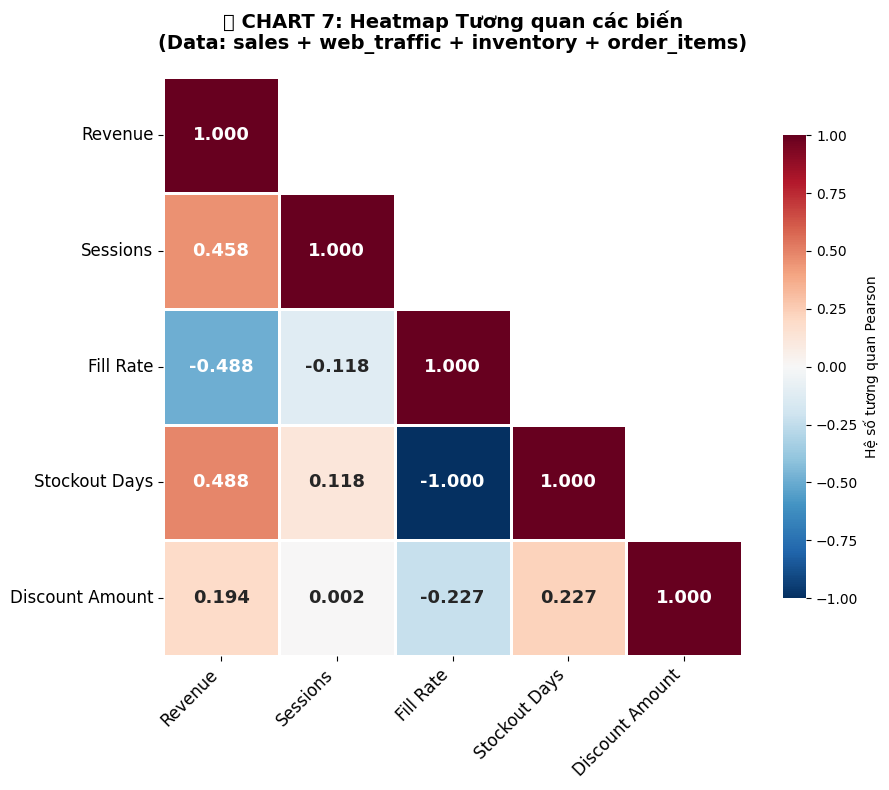


📌 Correlation Matrix:


,Revenue,sessions,fill_rate,stockout_days,discount_amount
Revenue,1.000,0.458,-0.488,0.488,0.194
sessions,0.458,1.000,-0.118,0.118,0.002
fill_rate,-0.488,-0.118,1.000,-1.000,-0.227
stockout_days,0.488,0.118,-1.000,1.000,0.227
discount_amount,0.194,0.002,-0.227,0.227,1.000


In [34]:
# === CHART 7: HEATMAP TƯƠNG QUAN CÁC BIẾN ===
# Files: sales.csv + web_traffic.csv + inventory.csv + order_items.csv + orders.csv

# 1. Revenue theo tháng
sales['year_month'] = sales['Date'].dt.to_period('M')
monthly_rev = sales.groupby('year_month').agg(Revenue=('Revenue','sum'), COGS=('COGS','sum')).reset_index()
monthly_rev['ym'] = monthly_rev['year_month'].astype(str)

# 2. Web traffic theo tháng
web_traffic['year_month'] = web_traffic['date'].dt.to_period('M')
monthly_traffic = web_traffic.groupby('year_month').agg(sessions=('sessions','sum')).reset_index()
monthly_traffic['ym'] = monthly_traffic['year_month'].astype(str)

# 3. Inventory theo tháng
inventory['year_month'] = inventory['snapshot_date'].dt.to_period('M')
monthly_inv = inventory.groupby('year_month').agg(
    fill_rate=('fill_rate','mean'), stockout_days=('stockout_days','mean')
).reset_index()
monthly_inv['ym'] = monthly_inv['year_month'].astype(str)

# 4. Discount amount theo tháng
oi_date = order_items.merge(orders[['order_id','order_date']], on='order_id', how='left')
oi_date['order_date'] = pd.to_datetime(oi_date['order_date'])
oi_date['year_month'] = oi_date['order_date'].dt.to_period('M')
monthly_disc = oi_date.groupby('year_month').agg(discount_amount=('discount_amount','sum')).reset_index()
monthly_disc['ym'] = monthly_disc['year_month'].astype(str)

# 5. Merge tất cả
corr_df = monthly_rev[['ym','Revenue']].merge(
    monthly_traffic[['ym','sessions']], on='ym', how='inner'
).merge(
    monthly_inv[['ym','fill_rate','stockout_days']], on='ym', how='inner'
).merge(
    monthly_disc[['ym','discount_amount']], on='ym', how='inner'
)

# 6. Correlation Matrix
corr_cols = ['Revenue','sessions','fill_rate','stockout_days','discount_amount']
corr_matrix = corr_df[corr_cols].corr()

# Vẽ Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=2, vmin=-1, vmax=1,
            annot_kws={'size': 13, 'fontweight': 'bold'},
            cbar_kws={'label': 'Hệ số tương quan Pearson', 'shrink': 0.8}, ax=ax)

labels = ['Revenue', 'Sessions', 'Fill Rate', 'Stockout Days', 'Discount Amount']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(labels, rotation=0, fontsize=12)
ax.set_title('📊 CHART 7: Heatmap Tương quan các biến\n(Data: sales + web_traffic + inventory + order_items)',
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('\n📌 Correlation Matrix:')
corr_matrix.round(3)

In [ ]:
# === CHART 8: INVENTORY STOCKOUT vs REVENUE THEO THÁNG ===
# Files: inventory.csv + sales.csv

chart8_df = monthly_rev[['ym','Revenue']].merge(
    monthly_inv[['ym','stockout_days']], on='ym', how='inner'
)
chart8_df['date'] = pd.to_datetime(chart8_df['ym'])
chart8_recent = chart8_df[chart8_df['date'] >= '2018-01-01'].sort_values('date').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(18, 7))

# Bar: Stockout days
color_bar = '#EF4444'
ax1.bar(range(len(chart8_recent)), chart8_recent['stockout_days'],
        color=color_bar, alpha=0.6, label='Stockout Days (TB)', width=0.7)
ax1.set_ylabel('Số ngày hết hàng TB (Stockout Days)', fontweight='bold', color=color_bar, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_bar)

# Line: Revenue (trục phụ)
ax2 = ax1.twinx()
color_line = '#2563EB'
ax2.plot(range(len(chart8_recent)), chart8_recent['Revenue'],
         color=color_line, marker='o', linewidth=2, markersize=4, label='Revenue')
ax2.set_ylabel('Doanh thu (Revenue)', fontweight='bold', color=color_line, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f} Tỷ'))

# X-axis labels
step = 3
ax1.set_xticks(range(0, len(chart8_recent), step))
ax1.set_xticklabels(chart8_recent['ym'].iloc[::step], rotation=45, ha='right')

# Highlight tháng stockout cao
threshold = chart8_recent['stockout_days'].quantile(0.75)
for i, row in chart8_recent.iterrows():
    if row['stockout_days'] > threshold:
        ax1.annotate('⚠️', xy=(i, row['stockout_days']), fontsize=12, ha='center', va='bottom')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, frameon=True)

ax1.set_title('📊 CHART 8: Inventory Stockout vs Revenue theo Tháng (2018-2022)\n(Data: inventory.csv + sales.csv)',
              fontweight='bold', fontsize=14, pad=15)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

corr_val = chart8_df['stockout_days'].corr(chart8_df['Revenue'])
print(f'\n📌 Tương quan Stockout Days vs Revenue: {corr_val:.4f}')
print('📌 Top 5 tháng stockout cao nhất:')
chart8_df.nlargest(5, 'stockout_days')[['ym','stockout_days','Revenue']]

[I 2026-04-28 15:10:03,412] A new study created in memory with name: no-name-13255ce8-72e6-49dd-adb4-1c4ece82455f
[I 2026-04-28 15:13:37,929] Trial 0 finished with value: 833212.3590174492 and parameters: {'iterations': 949, 'depth': 9, 'learning_rate': 0.026454651136852875, 'l2_leaf_reg': 1.351045486853677, 'bagging_temperature': 0.5215542046959042, 'random_strength': 1.1824037508059972, 'border_count': 183, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 833212.3590174492.
[I 2026-04-28 15:14:54,233] Trial 1 finished with value: 822667.6745590748 and parameters: {'iterations': 1331, 'depth': 8, 'learning_rate': 0.009865073865415184, 'l2_leaf_reg': 5.49513716875612, 'bagging_temperature': 0.06119842953441812, 'random_strength': 1.7774685065566265, 'border_count': 148, 'grow_policy': 'SymmetricTree'}. Best is trial 1 with value: 822667.6745590748.
[I 2026-04-28 15:14:54,235] A new study created in memory with name: no-name-fa320283-18ac-4ab3-925b-698f75dce68c
[I 2026-04-28 15:

Evaluating Revenue Model Feature Importance...


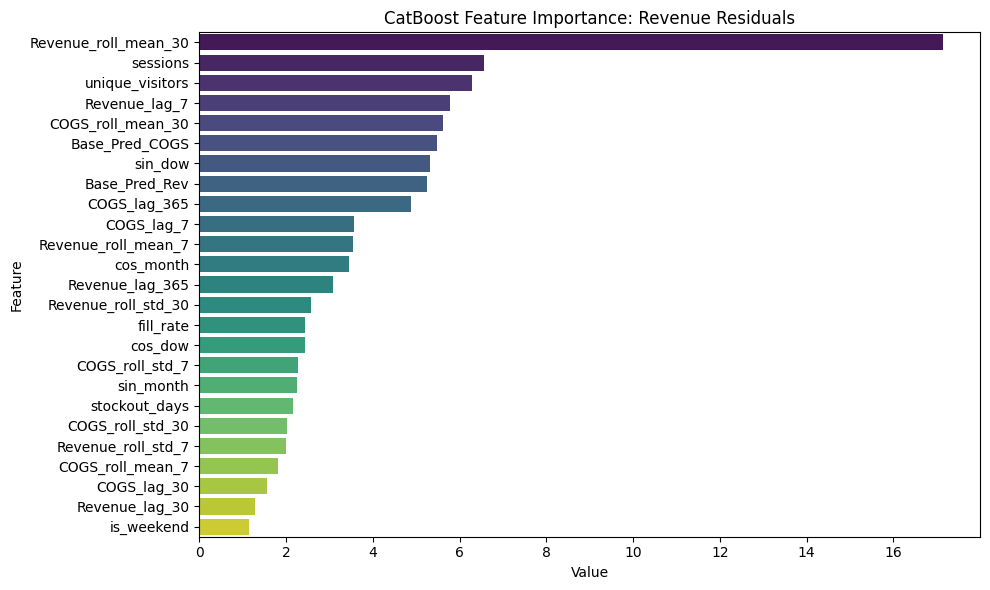

Evaluating COGS Model Feature Importance...


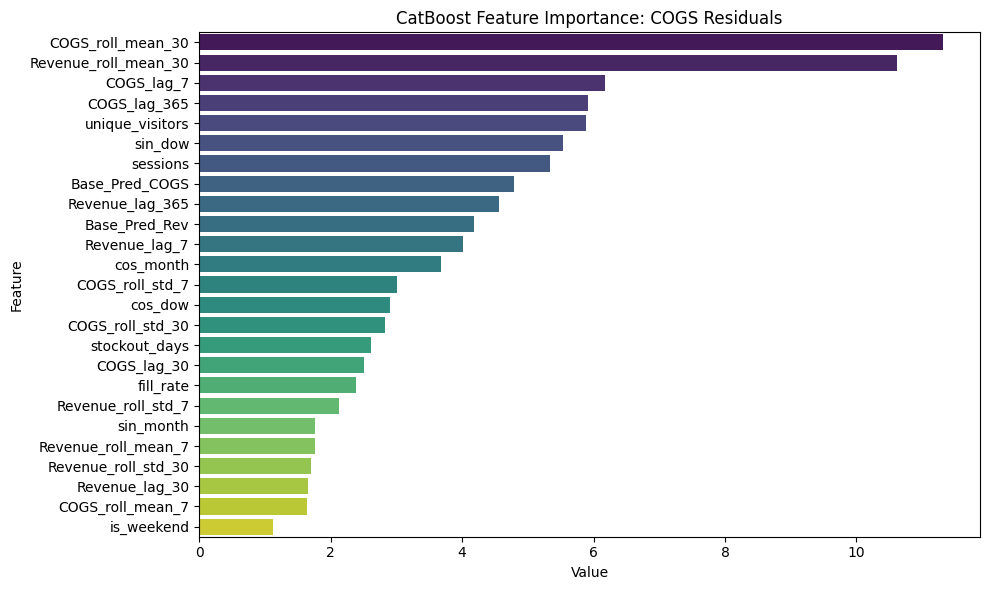


Top 8 features for Revenue model: ['Revenue_roll_mean_30', 'sessions', 'unique_visitors', 'Revenue_lag_7', 'COGS_roll_mean_30', 'Base_Pred_COGS', 'sin_dow', 'Base_Pred_Rev']
Top 8 features for COGS model: ['COGS_roll_mean_30', 'Revenue_roll_mean_30', 'COGS_lag_7', 'COGS_lag_365', 'unique_visitors', 'sin_dow', 'sessions', 'Base_Pred_COGS']

Original Revenue Model MAE (all features): 446645.34
Original COGS Model MAE (all features): 181203.92

Training Revenue Model with selected features...
Training COGS Model with selected features...
Selected Features Revenue Model MAE: 532191.62
Selected Features COGS Model MAE: 259434.18

--- Accuracy Improvement Analysis ---
Revenue Model accuracy DID NOT improve (or worsened) using selected features.
COGS Model accuracy DID NOT improve (or worsened) using selected features.


In [42]:
"""
Time-Series Forecasting Pipeline for Revenue and COGS
This script engineers advanced temporal and operational features, calculates a macro-economic
base trend, optimizes a CatBoost regressor using Optuna with TimeSeriesSplit, and performs
feature selection to improve forecasting accuracy on a 1.5-year horizon.
"""

import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Constants
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# =============================================================================
# 1. Advanced Feature Engineering with Inventory Context
# =============================================================================
def create_advanced_features(df, inv_df=None):
    """
    Engineers temporal dynamics, cyclical calendar features, operational inventory
    metrics, and rolling/lagged historical features.

    Args:
        df (pd.DataFrame): The primary dataframe containing 'Date' and target variables.
        inv_df (pd.DataFrame, optional): Inventory dataframe containing 'snapshot_date',
                                         'stockout_days', and 'fill_rate'. Defaults to None.

    Returns:
        pd.DataFrame: A new dataframe enriched with engineered features, with NaNs filled with 0.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    # Temporal Dynamics
    df['month'] = df['Date'].dt.month.astype(int)
    df['day'] = df['Date'].dt.day.astype(int)

    # Cyclical encoding to allow the model to understand the continuous nature of time
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_dow'] = np.cos(2 * np.pi * df['Date'].dt.dayofweek / 7)
    df['sin_dow'] = np.sin(2 * np.pi * df['Date'].dt.dayofweek / 7)
    df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

    # Inventory Context (Operational Layer)
    if inv_df is not None:
        # Aggregate inventory to a daily-accessible format (monthly snapshots)
        inv_df['snapshot_date'] = pd.to_datetime(inv_df['snapshot_date'])
        # Create monthly features: avg stockout days and fill rate across all products
        inv_monthly = inv_df.groupby(['year', 'month'])[['stockout_days', 'fill_rate']].mean().reset_index()
        df = df.merge(inv_monthly, on=['year', 'month'], how='left')

    # Lags and Rolling Windows
    # Creates historical lookbacks to capture momentum and volatility
    for col in ['Revenue', 'COGS']:
        if col in df.columns:
            # Shift by explicit days to avoid data leakage into the test set
            for lag in [7, 30, 365]:
                df[f'{col}_lag_{lag}'] = df[col].shift(lag)
            # Rolling means and standard deviations to capture short-term trends
            for w in [7, 30]:
                df[f'{col}_roll_mean_{w}'] = df[col].shift(1).rolling(w).mean()
                df[f'{col}_roll_std_{w}'] = df[col].shift(1).rolling(w).std()

    return df.fillna(0)

# =============================================================================
# 2. Dynamic Weighting & Multi-Horizon Setup
# =============================================================================
def get_seasonal_base(train_df):
    """
    Splits the training data to calculate long-term macro growth rates and
    extracts daily normalized seasonality profiles.

    Args:
        train_df (pd.DataFrame): The historical training dataset.

    Returns:
        tuple: Contains the seasonal profile DataFrame, Revenue growth rate,
               COGS growth rate, 2022 Revenue base value, and 2022 COGS base value.
    """
    df = train_df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month.astype(int)
    df['day'] = df['Date'].dt.day.astype(int)

    annual = df.groupby('year')[['Revenue', 'COGS']].mean()

    # Growth rates from 2020 to 2022 to capture recent momentum
    g_rev = (annual.loc[2022, 'Revenue'] / annual.loc[2020, 'Revenue']) ** (1/10)
    g_cogs = (annual.loc[2022, 'COGS'] / annual.loc[2020, 'COGS']) ** (1/10)

    # Normalize daily values against the annual mean to find pure seasonality
    a_means = df.groupby('year')[['Revenue','COGS']].transform('mean')
    df['rev_norm_val'] = df['Revenue'] / a_means['Revenue']
    df['cogs_norm_val'] = df['COGS'] / a_means['COGS']

    # Average the normalized values across all years for each specific day
    seasonal = df.groupby(['month', 'day'])[['rev_norm_val', 'cogs_norm_val']].mean().reset_index()
    seasonal.rename(columns={'rev_norm_val': 'rev_norm', 'cogs_norm_val': 'cogs_norm'}, inplace=True)

    return seasonal, g_rev, g_cogs, annual.loc[2022, 'Revenue'], annual.loc[2022, 'COGS']

# --- Data Preparation Execution ---
sales['Date'] = pd.to_datetime(sales['Date'])
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

# Extract macro trends
seasonal, g_rev, g_cogs, b_rev, b_cogs = get_seasonal_base(sales)

# Nullify targets in the submission file to strictly prevent data leakage during rolling calculations
sample_sub['Revenue'] = np.nan
sample_sub['COGS'] = np.nan

# Combine train and test for unified feature engineering
combined = pd.concat([sales, sample_sub], ignore_index=True)
combined = create_advanced_features(combined, inventory)
combined = combined.merge(seasonal[['month', 'day', 'rev_norm', 'cogs_norm']], on=['month', 'day'], how='left')
combined[['rev_norm', 'cogs_norm']] = combined[['rev_norm', 'cogs_norm']].fillna(1.0)

# Merge Web Traffic operational data
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
combined = combined.merge(web_traffic, left_on='Date', right_on='date', how='left').drop('date', axis=1).fillna(0)

# Calculate Base Predictions for the multi-horizon test set (Extrapolation Layer)
combined['years_ahead'] = (combined['Date'].dt.year - 2022).clip(lower=0)
combined['Base_Pred_Rev'] = b_rev * (g_rev ** combined['years_ahead']) * combined['rev_norm']
combined['Base_Pred_COGS'] = b_cogs * (g_cogs ** combined['years_ahead']) * combined['cogs_norm']

# Split back into train and test sets
train = combined.iloc[:len(sales)].copy()
test = combined.iloc[len(sales):].copy()

# Define the final feature space used for modeling
features = ['cos_month', 'sin_month', 'cos_dow', 'sin_dow', 'is_weekend', 'sessions',
            'unique_visitors', 'Base_Pred_Rev', 'Base_Pred_COGS', 'Revenue_lag_365',
            'COGS_lag_365', 'Revenue_roll_mean_7', 'stockout_days', 'fill_rate',
            'Revenue_roll_std_7', 'COGS_roll_mean_7', 'COGS_roll_std_7',
            'Revenue_roll_mean_30', 'Revenue_roll_std_30', 'COGS_roll_mean_30', 'COGS_roll_std_30',
            'Revenue_lag_30', 'Revenue_lag_7', 'COGS_lag_7', 'COGS_lag_30']

# =============================================================================
# 3. Expanded Hyperparameter Tuning with Complex Parameters
# =============================================================================
def objective_cv(trial, X, y):
    """
    Optuna objective function for tuning CatBoost hyperparameters using TimeSeriesSplit.

    Args:
        trial (optuna.trial.Trial): The current optimization trial.
        X (pd.DataFrame): The feature matrix.
        y (pd.Series): The target variable (residuals).

    Returns:
        float: The average Mean Absolute Error (MAE) across all cross-validation folds.
    """
    param = {
        "iterations": trial.suggest_int("iterations", 800, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1.0, 2.0),
        "border_count": trial.suggest_int("border_count", 128, 254),
        "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]),
        "loss_function": "MAE", # MAE is robust to outliers
        "random_seed": RANDOM_SEED,
        "verbose": 0
    }

    # TimeSeriesSplit ensures no future data leaks into training folds
    tscv = TimeSeriesSplit(n_splits=5)
    mae_scores = []

    for train_index, val_index in tscv.split(X):
        X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
        y_tr, y_val = y.iloc[train_index], y.iloc[val_index]

        model = CatBoostRegressor(**param)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100, verbose=0)
        mae_scores.append(mean_absolute_error(y_val, model.predict(X_val)))

    return np.mean(mae_scores)

# --- Tuning and Prediction Execution ---
# Tune for Revenue Residuals (Actual - Base Prediction)
study_rev = optuna.create_study(direction='minimize')
study_rev.optimize(lambda t: objective_cv(t, train[features], train['Revenue'] - train['Base_Pred_Rev']), n_trials=2)

# Tune for COGS Residuals (Actual - Base Prediction)
study_cogs = optuna.create_study(direction='minimize')
study_cogs.optimize(lambda t: objective_cv(t, train[features], train['COGS'] - train['Base_Pred_COGS']), n_trials=2)

# Train Final Baseline Models
model_rev = CatBoostRegressor(**study_rev.best_params, verbose=0, random_seed=RANDOM_SEED)
model_rev.fit(train[features], train['Revenue'] - train['Base_Pred_Rev'])

model_cogs = CatBoostRegressor(**study_cogs.best_params, verbose=0, random_seed=RANDOM_SEED)
model_cogs.fit(train[features], train['COGS'] - train['Base_Pred_COGS'])

# =============================================================================
# 4. Important Features Extraction & Model Refinement
# =============================================================================
def plot_feature_importance(model, features, title, return_df=False):
    """
    Visualizes and optionally extracts the feature importance scores from a trained model.

    Args:
        model (CatBoostRegressor): The trained model.
        features (list): List of feature names matching the model's training data.
        title (str): Title for the generated plot.
        return_df (bool, optional): Whether to return the underlying DataFrame. Defaults to False.

    Returns:
        pd.DataFrame or None: The feature importance DataFrame if return_df is True.
    """
    importance = model.get_feature_importance()
    feature_imp = pd.DataFrame({'Value': importance, 'Feature': features}).sort_values(by="Value", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Value", y="Feature", data=feature_imp, palette='viridis')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    if return_df:
        return feature_imp
    return None

def get_top_n_features(feature_importance_df, n):
    """
    Extracts the top N most important features from the importance DataFrame.
    """
    return feature_importance_df.head(n)['Feature'].tolist()

# Extract and plot feature importances
print("Evaluating Revenue Model Feature Importance...")
feature_imp_rev = plot_feature_importance(model_rev, features, "CatBoost Feature Importance: Revenue Residuals", return_df=True)

print("Evaluating COGS Model Feature Importance...")
feature_imp_cogs = plot_feature_importance(model_cogs, features, "CatBoost Feature Importance: COGS Residuals", return_df=True)

# Select top features to reduce noise and prevent overfitting
N_TOP_FEATURES = 8
top_features_rev = get_top_n_features(feature_imp_rev, N_TOP_FEATURES)
print(f"\nTop {N_TOP_FEATURES} features for Revenue model: {top_features_rev}")

top_features_cogs = get_top_n_features(feature_imp_cogs, N_TOP_FEATURES)
print(f"Top {N_TOP_FEATURES} features for COGS model: {top_features_cogs}")

# =============================================================================
# 5. Model Accuracy Comparison and Final Test Set Prediction
# =============================================================================
best_params_rev = study_rev.best_params
best_params_cogs = study_cogs.best_params

# Calculate baseline training MAE (using all features)
y_train_rev_residual = train['Revenue'] - train['Base_Pred_Rev']
y_train_cogs_residual = train['COGS'] - train['Base_Pred_COGS']

preds_rev_full = model_rev.predict(train[features])
mae_rev_full = mean_absolute_error(y_train_rev_residual, preds_rev_full)

preds_cogs_full = model_cogs.predict(train[features])
mae_cogs_full = mean_absolute_error(y_train_cogs_residual, preds_cogs_full)

print(f"\nOriginal Revenue Model MAE (all features): {mae_rev_full:.2f}")
print(f"Original COGS Model MAE (all features): {mae_cogs_full:.2f}")

# Train refined models strictly on the top N features
print("\nTraining Revenue Model with selected features...")
model_rev_selected = CatBoostRegressor(**best_params_rev, verbose=0, random_seed=RANDOM_SEED)
model_rev_selected.fit(train[top_features_rev], y_train_rev_residual)

print("Training COGS Model with selected features...")
model_cogs_selected = CatBoostRegressor(**best_params_cogs, verbose=0, random_seed=RANDOM_SEED)
model_cogs_selected.fit(train[top_features_cogs], y_train_cogs_residual)

# Calculate refined training MAE
preds_rev_selected = model_rev_selected.predict(train[top_features_rev])
mae_rev_selected = mean_absolute_error(y_train_rev_residual, preds_rev_selected)

preds_cogs_selected = model_cogs_selected.predict(train[top_features_cogs])
mae_cogs_selected = mean_absolute_error(y_train_cogs_residual, preds_cogs_selected)

print(f"Selected Features Revenue Model MAE: {mae_rev_selected:.2f}")
print(f"Selected Features COGS Model MAE: {mae_cogs_selected:.2f}")

# --- Final Accuracy Decision Protocol ---
# Evaluate if feature pruning improved training MAE.
# Select the best performing model architecture to generate final test predictions.
print("\n--- Accuracy Improvement Analysis ---")
if mae_rev_selected < mae_rev_full:
    test['Revenue'] = test['Base_Pred_Rev'] + model_rev_selected.predict(test[top_features_rev])
    print(f"Revenue Model accuracy IMPROVED by {((mae_rev_full - mae_rev_selected) / mae_rev_full) * 100:.2f}% using selected features.")
else:
    print(f"Revenue Model accuracy DID NOT improve (or worsened) using selected features.")
    test['Revenue'] = (test['Base_Pred_Rev'] + model_rev.predict(test[features])).clip(0)

if mae_cogs_selected < mae_cogs_full:
    test['COGS'] = test['Base_Pred_COGS'] + model_cogs_selected.predict(test[top_features_cogs])
    print(f"COGS Model accuracy IMPROVED by {((mae_cogs_full - mae_cogs_selected) / mae_cogs_full) * 100:.2f}% using selected features.")
else:
    print(f"COGS Model accuracy DID NOT improve (or worsened) using selected features.")
    test['COGS'] = (test['Base_Pred_COGS'] + model_cogs.predict(test[features])).clip(0)

In [43]:
# 5. submission.csv export
submission = test[['Date', 'Revenue', 'COGS']]
submission.to_csv('submission.csv', index=False)
print("CV-Optimized Submission generated.")
display(submission)

CV-Optimized Submission generated.


,Date,Revenue,COGS
3833,2023-01-01,3.170054e+06,2.677771e+06
3834,2023-01-02,1.886438e+06,1.660416e+06
3835,2023-01-03,1.623502e+06,1.599070e+06
3836,2023-01-04,1.795524e+06,1.700462e+06
3837,2023-01-05,1.730759e+06,1.543751e+06
...,...,...,...
4376,2024-06-27,5.665537e+06,5.552027e+06
4377,2024-06-28,6.119246e+06,5.967032e+06
4378,2024-06-29,8.248059e+06,7.949137e+06
4379,2024-06-30,7.031633e+06,6.598589e+06


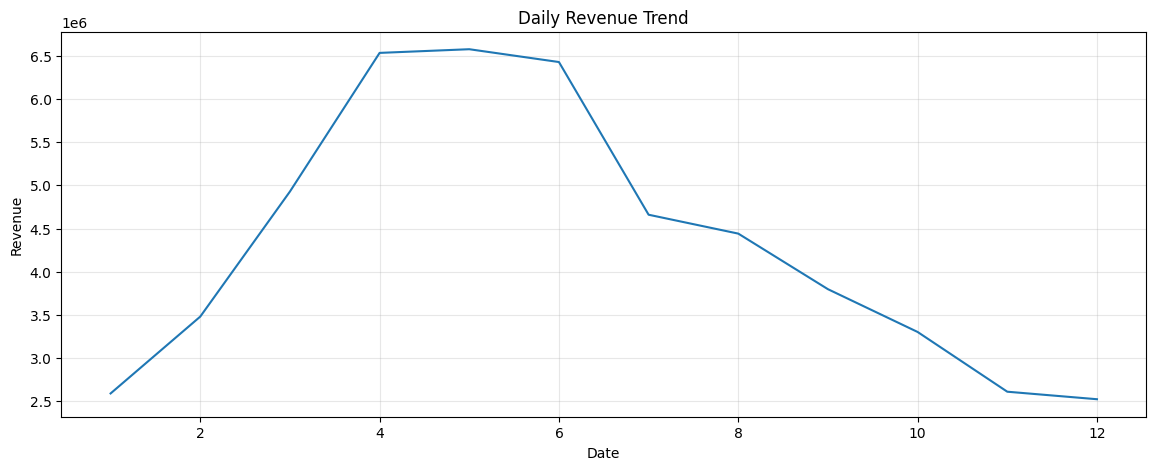

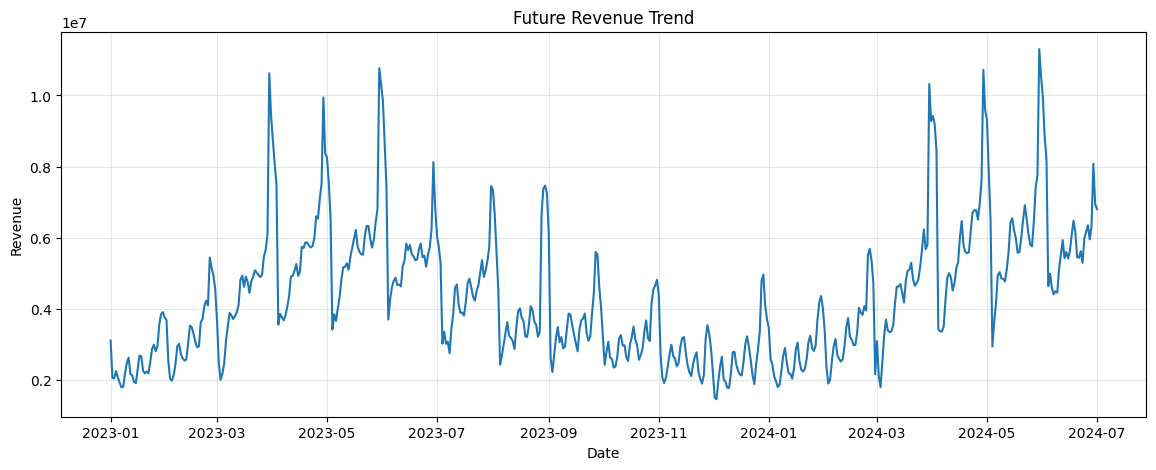

In [41]:
    # Tạo biểu đồ rộng 14 inch, cao 5 inch
    plt.figure(figsize=(14, 5))

    # Vẽ doanh thu theo tháng
    tmp = sales.groupby('month')['Revenue'].mean()
    plt.plot(tmp.index, tmp)

    # Đặt tiêu đề và nhãn trục
    plt.title("Daily Revenue Trend")
    plt.xlabel("Date")
    plt.ylabel("Revenue")

    # Thêm lưới mờ để dễ đọc
    plt.grid(alpha=0.3)

    # Hiển thị biểu đồ
    plt.show()

    # Tạo biểu đồ rộng 14 inch, cao 5 inch
    plt.figure(figsize=(14, 5))

    # Vẽ doanh thu theo ngày
    plt.plot(submission["Date"], submission["Revenue"])

    # Đặt tiêu đề và nhãn trục
    plt.title("Future Revenue Trend")
    plt.xlabel("Date")
    plt.ylabel("Revenue")

    # Thêm lưới mờ để dễ đọc
    plt.grid(alpha=0.3)

    # Hiển thị biểu đồ
    plt.show()